In [ ]:
#TODO: fix the SVM code to work with linear kernel

import numpy as np

class SVM:
    def __init__(self, kernel="gaussian", learning_rate=1e-5, max_iterations=1000, sigma=0.1, regularization_param=1.0):
        self.learning_rate = learning_rate
        self.max_iterations = max_iterations
        self.C = regularization_param
        self.alpha = None
        self.b = 0
        
        self.kernel = None
        if kernel == "linear":
            self.kernel = self.linear_kernel
            
        if kernel == "gaussian":
            self.kernel = self.gaussian_kernel
            self.sigma = sigma
    
    def linear_kernel(self, X, Z):
        return np.dot(X, Z.T)
    
    def gaussian_kernel(self, X, Z):
        # -||X-Z||^2 / 2sigma^2
        return np.exp((-1/(2 * self.sigma**2)) * np.linalg.norm(X[:, np.newaxis] - Z[np.newaxis, :], axis=2) ** 2)
    
    def fit(self, X, y):
        self.X = X
        self.y = y
        self.alpha = np.random.random(X.shape[0])
        self.b = 0
        
        y_mul_kernel = np.outer(y, y) * self.kernel(X, X) # yi yj K(xi, xj)
        for i in range(self.max_iterations):
            # 1 – yk ∑ αj yj K(xj, xk)
            gradient = np.ones(X.shape[0])  - y_mul_kernel.dot(self.alpha)

            # maximize the loss function
            # α = α + learning_rate * (1 – yk ∑ αj yj K(xj, xk))
            self.alpha += self.learning_rate * gradient 
            
            # Appling limits 0<α<C
            self.alpha[self.alpha > self.C] = self.C 
            self.alpha[self.alpha < 0] = 0

            # ∑αi – 0.5 * ∑i ∑j αi αj yi yj K(xi, xj)
            loss = np.sum(self.alpha) - 0.5 * np.sum(np.outer(self.alpha, self.alpha) * y_mul_kernel)
            print(f"Iteration {i+1}/{self.max_iterations}, loss: {loss}")
            
        alpha_index = np.where((self.alpha > 0) & (self.alpha < self.C))[0]
        
        # for intercept b, we will only consider α which are 0<α<C 
        b_list = []        
        for index in alpha_index:
            b_list.append(y[index] - (self.alpha * y).dot(self.kernel(X, X[index])))

        self.b = np.mean(b_list) # avgC≤αi≤0{ yi – ∑αjyj K(xj, xi) }
    
    def predict(self, X):
        # h(x) = g(∑ αi yi K(xi, x) + b)
        return np.sign((self.alpha * self.y).dot(self.kernel(self.X, X)) + self.b)

Iteration 1/100, loss: -32.44850335506316
Iteration 2/100, loss: -21.4158039466537
Iteration 3/100, loss: -15.637513387284894
Iteration 4/100, loss: -11.416186042977365
Iteration 5/100, loss: -8.332261622879788
Iteration 6/100, loss: -6.4086480743312855
Iteration 7/100, loss: -5.003189252157609
Iteration 8/100, loss: -3.906195283220029
Iteration 9/100, loss: -3.133733743781108
Iteration 10/100, loss: -2.537312146913722
Iteration 11/100, loss: -2.1613538080035113
Iteration 12/100, loss: -1.858655420759327
Iteration 13/100, loss: -1.598481986157871
Iteration 14/100, loss: -1.3925357667517348
Iteration 15/100, loss: -1.2895746411527347
Iteration 16/100, loss: -1.1941189752043346
Iteration 17/100, loss: -1.105572466566746
Iteration 18/100, loss: -1.0233975604153236
Iteration 19/100, loss: -0.9471072417583416
Iteration 20/100, loss: -0.8762583897290415
Iteration 21/100, loss: -0.8274259496460694
Iteration 22/100, loss: -0.7884577324499589
Iteration 23/100, loss: -0.751438910678219
Iteration

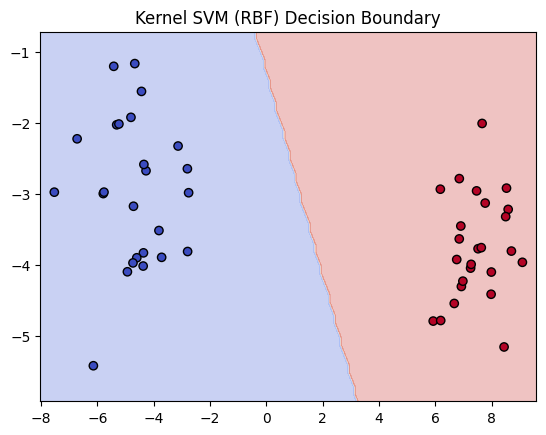

In [37]:
from sklearn.datasets import make_circles, make_moons, make_blobs
import matplotlib.pyplot as plt

# Generate non-linear data
# X, y = make_circles(n_samples=100, factor=0.5, noise=0.1)
# X, y = make_moons(n_samples=150, noise=0.15, random_state=42)
X, y = make_blobs(
    n_samples=50, n_features=2, centers=2, cluster_std=1.05
)
y = np.where(y == 0, -1, 1)

# Fit Kernel SVM
# ksvm = SVM(kernel="gaussian", sigma=1.0, learning_rate=1e-3, max_iterations=100, regularization_param=1.0)
ksvm = SVM(kernel="linear", learning_rate=1e-3, max_iterations=100, regularization_param=1.0)

ksvm.fit(X, y)

# Create a meshgrid for plotting
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

Z = ksvm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
plt.title("Kernel SVM (RBF) Decision Boundary")
plt.show()